# Swarabyanjan — Clean Balanced Dataset (766 articles)

**BanglaBERT Large + Classical Baselines on the 766-Article Gold Standard**

Dataset: `Swarabyanjan_BEST_BALANCED_1to1.csv` (383 yellow + 383 non-yellow)

- 5-fold Stratified Cross-Validation
- BanglaBERT Large (csebuetnlp/banglabert_large)
- Classical: Logistic Regression, Random Forest, Linear SVM, XGBoost
- Auto GPU detection with CPU fallback
- Auto dataset path detection (Kaggle/local)

## Kaggle Setup

| Setting | Value |
|---------|-------|
| Accelerator | **GPU T4 ×2** |
| Internet | **On (for HuggingFace model download)** |
| Expected runtime | ~2 hours |

**Required Kaggle Inputs:**
- Dataset: `swagotammalakar/swarabyanjan` (provides `Swarabyanjan_Gold_Balanced_766.csv`)
- OR Dataset: `swagotammalakar/v18-human-gold-final`

> BanglaBERT Large model is downloaded from HuggingFace (csebuetnlp/banglabert_large).
>
> **Note:** If Kaggle resets the inputs/accelerator after re-importing the notebook, re-attach the dataset + model listed above and set accelerator to GPU T4 ×2 before running.


In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # MUST be before import torch to prevent DataParallel OOM

# === SETUP ===
import os, random, json, warnings, glob
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Auto-detect dataset path
DATASET_FILENAME = 'Swarabyanjan_BEST_BALANCED_1to1.csv'
DATA_PATH = None

# Try multiple locations
search_paths = [
    f'/kaggle/input/datasets/smalakarishere/swarabyanjan/{DATASET_FILENAME}',
    f'/kaggle/input/datasets/swagotammalakar/swarabyanjan/{DATASET_FILENAME}',
    f'/kaggle/input/swarabyanjan/{DATASET_FILENAME}',
    f'/kaggle/input/{DATASET_FILENAME}',
    f'/kaggle/input/*/{DATASET_FILENAME}',
    f'/kaggle/input/*/*/{DATASET_FILENAME}',
]
for p in search_paths:
    matches = glob.glob(p)
    if matches:
        DATA_PATH = matches[0]
        break

if DATA_PATH is None:
    # List all input dirs to help find it
    input_dirs = glob.glob('/kaggle/input/*/')
    print('Available input directories:', input_dirs)
    for d in input_dirs:
        csvs = glob.glob(f'{d}*.csv')
        if csvs:
            print(f'  {d}: {csvs}')
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME}. Please check your Kaggle dataset.')

print(f'Dataset path: {DATA_PATH}')

OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. BanglaBERT will be very slow on CPU.')

Dataset path: /kaggle/input/datasets/smalakarishere/swarabyanjan/Swarabyanjan_BEST_BALANCED_1to1.csv
Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [2]:
# === LOAD DATA ===
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

# Auto-detect column names (balanced CSV may use different names)
HEADLINE_COL = None
BODY_COL = None
LABEL_COL = None

for col in df.columns:
    cl = col.lower().strip()
    if cl in ('headline', 'headlines', 'title'):
        HEADLINE_COL = col
    elif cl in ('body_text', 'body text', 'body_preview', 'body', 'content', 'article_text', 'full_text'):
        BODY_COL = col
    elif cl in ('best_label', 'my_label', 'label', 'class', 'category', 'is_yellow', 'weak_label'):
        LABEL_COL = col

print(f'Detected: headline={HEADLINE_COL}, body={BODY_COL}, label={LABEL_COL}')

if LABEL_COL is None:
    raise ValueError(f'No label column found. Available: {list(df.columns)}')

if HEADLINE_COL:
    df['headline'] = df[HEADLINE_COL].fillna('')
else:
    df['headline'] = ''
    print('WARNING: No headline column found, using empty string')

if BODY_COL:
    df['body_text'] = df[BODY_COL].fillna('')
else:
    raise ValueError(f'No body text column found. Available: {list(df.columns)}')

df['text'] = df['headline'] + ' ' + df['body_text']

print(f'\nLabel distribution:')
print(df[LABEL_COL].value_counts())
print(f'\nText length stats:')
print(df['text'].str.len().describe().round(0))
df.head(3)

Shape: (766, 8)
Columns: ['article_id', 'headline', 'body_text', 'news_source', 'article_length', 'best_label', 'best_confidence', 'best_note']
Detected: headline=headline, body=body_text, label=best_label

Label distribution:
best_label
0    383
1    383
Name: count, dtype: int64

Text length stats:
count     766.0
mean     1622.0
std      1174.0
min        32.0
25%       929.0
50%      1248.0
75%      1946.0
max      8245.0
Name: text, dtype: float64


,article_id,headline,body_text,news_source,article_length,best_label,best_confidence,best_note,text
0,v18_2830,কুমিল্লায় ‘ডাকাতের গুলিতে ডাকাত’ নিহত,"দাউদকান্দিথানার ওসি মিজানুর রহমান বলেন, “দুই দ...",corpus_expansion_5000,684,0,H,Crime news with named Daudkandi OC Mizanur Rah...,কুমিল্লায় ‘ডাকাতের গুলিতে ডাকাত’ নিহত দাউদকান্...
1,v18_0000,২০১৮ সালে বিশ্বজুড়ে ৯৭ সাংবাদিক খুন,বিশ্বজুড়ে সাংবাদিকদের ওপর হামলার ঘটনাগুলোতে বি...,new_low_w0_pany,2543,0,H,Factual international press-freedom report wit...,২০১৮ সালে বিশ্বজুড়ে ৯৭ সাংবাদিক খুন বিশ্বজুড়ে ...
2,v18_4780,বিশ্বকাপে আফগানদের বিপক্ষে টেস্ট খেললেন ধোনি?,খেলা শুরুর আগেই 'ফেভারিট বনাম লাস্টবয়' শিরোনাম...,corpus_expansion_5000,960,1,M,[R1-BROADER] Clickbait sports headline ('?'); ...,বিশ্বকাপে আফগানদের বিপক্ষে টেস্ট খেললেন ধোনি? ...


In [3]:
# === IMPORTS FOR MODELS ===
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, matthews_corrcoef,
                             roc_auc_score, confusion_matrix, classification_report)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available, skipping')

N_FOLDS = 5
X = df['text'].values
y = df[LABEL_COL].values
folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
print(f'Fold sizes: {[len(v) for _, v in folds]}')
print(f'Total: {len(X)} | Yellow: {y.sum()} | Non-yellow: {(y==0).sum()}')

Fold sizes: [154, 153, 153, 153, 153]
Total: 766 | Yellow: 383 | Non-yellow: 383


In [4]:
# === METRICS FUNCTION ===
def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        m['roc_auc'] = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0
    else:
        m['roc_auc'] = 0.0
    return m

def run_classical_cv(model_factory, X_text, y, folds, method_name='', use_calibration=False):
    all_preds = np.zeros(len(y), dtype=int)
    all_probs = np.full(len(y), np.nan)
    fold_results = []
    
    for fold_i, (train_idx, val_idx) in enumerate(folds):
        # TF-IDF fit on train only
        tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
        X_train = tfidf.fit_transform(X_text[train_idx])
        X_val = tfidf.transform(X_text[val_idx])
        
        model = model_factory()
        if use_calibration:
            model = CalibratedClassifierCV(model, cv=3, method='sigmoid')
        
        model.fit(X_train, y[train_idx])
        preds = model.predict(X_val)
        
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_val)[:, 1]
        else:
            probs = preds.astype(float)
        
        all_preds[val_idx] = preds
        all_probs[val_idx] = probs
        
        m = compute_metrics(y[val_idx], preds, probs)
        m['fold'] = fold_i + 1
        fold_results.append(m)
        print(f'  {method_name} Fold {fold_i+1}: F1={m["f1"]:.4f} Acc={m["accuracy"]:.4f}')
    
    overall = compute_metrics(y, all_preds, all_probs)
    fold_df = pd.DataFrame(fold_results)
    summary = {
        'method': method_name,
        'accuracy_mean': fold_df['accuracy'].mean(),
        'accuracy_std': fold_df['accuracy'].std(),
        'precision_mean': fold_df['precision'].mean(),
        'precision_std': fold_df['precision'].std(),
        'recall_mean': fold_df['recall'].mean(),
        'recall_std': fold_df['recall'].std(),
        'f1_mean': fold_df['f1'].mean(),
        'f1_std': fold_df['f1'].std(),
        'kappa_mean': fold_df['kappa'].mean(),
        'kappa_std': fold_df['kappa'].std(),
        'mcc_mean': fold_df['mcc'].mean(),
        'mcc_std': fold_df['mcc'].std(),
        'auc_mean': fold_df['roc_auc'].mean(),
        'auc_std': fold_df['roc_auc'].std(),
        'overall_metrics': overall,
        'all_preds': all_preds,
        'all_probs': all_probs,
    }
    print(f'\n{method_name} 5-Fold CV: F1={summary["f1_mean"]:.4f}±{summary["f1_std"]:.4f} '
          f'Kappa={summary["kappa_mean"]:.4f} AUC={summary["auc_mean"]:.4f}\n')
    return summary

In [5]:
# === CLASSICAL MODELS ===
print('='*60)
print('CLASSICAL BASELINES (5-Fold CV)')
print('='*60)

# 1. Logistic Regression
print('\n[1] Logistic Regression')
logreg_results = run_classical_cv(
    lambda: LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                               class_weight='balanced', random_state=SEED),
    X, y, folds, 'LogReg')

# 2. Random Forest
print('[2] Random Forest')
rf_results = run_classical_cv(
    lambda: RandomForestClassifier(n_estimators=200, max_depth=None,
                                   class_weight='balanced', random_state=SEED,
                                   n_jobs=-1),
    X, y, folds, 'RandomForest')

# 3. Linear SVM
print('[3] Linear SVM')
svm_results = run_classical_cv(
    lambda: LinearSVC(C=1.0, class_weight='balanced', max_iter=2000,
                      random_state=SEED),
    X, y, folds, 'LinearSVM', use_calibration=True)

# 4. XGBoost
if HAS_XGB:
    print('[4] XGBoost')
    xgb_results = run_classical_cv(
        lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             random_state=SEED, n_jobs=-1, eval_metric='logloss',
                             use_label_encoder=False),
        X, y, folds, 'XGBoost')
else:
    xgb_results = None

CLASSICAL BASELINES (5-Fold CV)

[1] Logistic Regression
  LogReg Fold 1: F1=0.7338 Acc=0.7597
  LogReg Fold 2: F1=0.8516 Acc=0.8497
  LogReg Fold 3: F1=0.7792 Acc=0.7778
  LogReg Fold 4: F1=0.7417 Acc=0.7451
  LogReg Fold 5: F1=0.7792 Acc=0.7778

LogReg 5-Fold CV: F1=0.7771±0.0466 Kappa=0.5641 AUC=0.8531

[2] Random Forest
  RandomForest Fold 1: F1=0.7808 Acc=0.7922
  RandomForest Fold 2: F1=0.7763 Acc=0.7778
  RandomForest Fold 3: F1=0.7898 Acc=0.7843
  RandomForest Fold 4: F1=0.7799 Acc=0.7712
  RandomForest Fold 5: F1=0.8125 Acc=0.8039

RandomForest 5-Fold CV: F1=0.7879±0.0146 Kappa=0.5717 AUC=0.8595

[3] Linear SVM
  LinearSVM Fold 1: F1=0.7534 Acc=0.7662
  LinearSVM Fold 2: F1=0.7947 Acc=0.7974
  LinearSVM Fold 3: F1=0.7547 Acc=0.7451
  LinearSVM Fold 4: F1=0.7568 Acc=0.7647
  LinearSVM Fold 5: F1=0.7582 Acc=0.7582

LinearSVM 5-Fold CV: F1=0.7636±0.0175 Kappa=0.5327 AUC=0.8493

[4] XGBoost
  XGBoost Fold 1: F1=0.7448 Acc=0.7597
  XGBoost Fold 2: F1=0.7568 Acc=0.7647
  XGBoost Fol

### BanglaBERT Large Fine-tuning

- Model: `csebuetnlp/banglabert_large` (ELECTRA-large)
- 5-fold CV, 4 epochs per fold
- LR=2e-5, batch=16, max_len=512, fp16
- ~18-22 min per fold on T4, ~90-120 min total

In [6]:
# === BANGLABERT SETUP ===

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)
from torch.utils.data import Dataset

MODEL_NAME = 'csebuetnlp/banglabert_large'
MAX_LEN = 512
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {len(tokenizer)}')

class BengaliNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts.tolist() if hasattr(texts, 'tolist') else list(texts)
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding=False,
        )
        return {
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask'],
            'labels': int(self.labels[idx]),
        }

def compute_metrics_for_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, zero_division=0),
        'kappa': cohen_kappa_score(labels, preds),
        'mcc': matthews_corrcoef(labels, preds),
        'roc_auc': roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.0,
    }

print('BanglaBERT classes defined.')


config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: csebuetnlp/banglabert_large
Vocab size: 32000
BanglaBERT classes defined.


In [7]:
# === BANGLABERT TRAINING (5-Fold CV) ===
banglabert_fold_results = []
banglabert_all_preds = np.zeros(len(y), dtype=int)
banglabert_all_probs = np.full(len(y), np.nan)

for fold_i, (train_idx, val_idx) in enumerate(folds):
    print(f'\n{"="*60}')
    print(f'BanglaBERT Fold {fold_i+1}/{N_FOLDS}')
    print(f'  train: {len(train_idx)} | val: {len(val_idx)}')
    print(f'{"="*60}')
    
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)
    
    train_ds = BengaliNewsDataset(X[train_idx], y[train_idx], tokenizer)
    val_ds = BengaliNewsDataset(X[val_idx], y[val_idx], tokenizer)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    fold_output_dir = OUTPUT_DIR / f'banglabert_fold_{fold_i+1}'
    fold_output_dir.mkdir(parents=True, exist_ok=True)
    
    training_args = TrainingArguments(
        output_dir=str(fold_output_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        logging_steps=50,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        save_total_limit=1,
        report_to='none',
        seed=SEED,
        fp16=True,
        gradient_accumulation_steps=1,
        dataloader_num_workers=2,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics_for_trainer,
    )
    
    trainer.train()
    eval_result = trainer.evaluate()
    print(f'  Fold {fold_i+1} eval: {eval_result}')
    
    predictions = trainer.predict(val_ds)
    logits = predictions.predictions
    fold_preds = np.argmax(logits, axis=-1)
    fold_probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    
    fold_metrics = compute_metrics(y[val_idx], fold_preds, fold_probs)
    fold_metrics['fold'] = fold_i + 1
    fold_metrics['train_loss'] = float(trainer.state.log_history[-1].get('train_loss', 0)) if trainer.state.log_history else 0
    banglabert_fold_results.append(fold_metrics)
    banglabert_all_preds[val_idx] = fold_preds
    banglabert_all_probs[val_idx] = fold_probs
    
    print(f'  Fold {fold_i+1} metrics: '
          f'acc={fold_metrics["accuracy"]:.4f}  '
          f'f1={fold_metrics["f1"]:.4f}  '
          f'kappa={fold_metrics["kappa"]:.4f}  '
          f'mcc={fold_metrics["mcc"]:.4f}  '
          f'auc={fold_metrics["roc_auc"]:.4f}')
    
    del model, trainer
    torch.cuda.empty_cache()

    # Delete fold checkpoints to free disk space
    import shutil
    if fold_output_dir.exists():
        shutil.rmtree(fold_output_dir)
        print(f'  Cleaned up {fold_output_dir}')

print('\n' + '='*60)
print('BANGLABERT 5-FOLD CV COMPLETE')
print('='*60)


BanglaBERT Fold 1/5
  train: 612 | val: 154


pytorch_model.bin:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert_large
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the ch

model.safetensors:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

  Fold 5 eval: {'eval_loss': 0.5375099778175354, 'eval_accuracy': 0.8431372549019608, 'eval_f1': 0.8536585365853658, 'eval_kappa': 0.6859928168291431, 'eval_mcc': 0.6919407519215276, 'eval_roc_auc': 0.9022556390977443, 'eval_runtime': 3.4458, 'eval_samples_per_second': 44.403, 'eval_steps_per_second': 1.451, 'epoch': 4.0}
  Fold 5 metrics: acc=0.8431  f1=0.8537  kappa=0.6860  mcc=0.6919  auc=0.9023
  Cleaned up /kaggle/working/banglabert_fold_5

BANGLABERT 5-FOLD CV COMPLETE


In [8]:
# === BANGLABERT RESULTS SUMMARY ===
banglabert_fold_df = pd.DataFrame(banglabert_fold_results)
print('Per-fold results:')
print(banglabert_fold_df[['fold', 'accuracy', 'precision', 'recall',
                          'f1', 'kappa', 'mcc', 'roc_auc']].to_string(index=False))

banglabert_summary = {
    'model': MODEL_NAME,
    'cv_folds': N_FOLDS,
    'gold_samples': int(len(y)),
    'yellow_samples': int(y.sum()),
    'non_yellow_samples': int((y == 0).sum()),
    'mean_accuracy': float(banglabert_fold_df['accuracy'].mean()),
    'std_accuracy': float(banglabert_fold_df['accuracy'].std()),
    'mean_precision': float(banglabert_fold_df['precision'].mean()),
    'std_precision': float(banglabert_fold_df['precision'].std()),
    'mean_recall': float(banglabert_fold_df['recall'].mean()),
    'std_recall': float(banglabert_fold_df['recall'].std()),
    'mean_f1': float(banglabert_fold_df['f1'].mean()),
    'std_f1': float(banglabert_fold_df['f1'].std()),
    'mean_kappa': float(banglabert_fold_df['kappa'].mean()),
    'std_kappa': float(banglabert_fold_df['kappa'].std()),
    'mean_mcc': float(banglabert_fold_df['mcc'].mean()),
    'std_mcc': float(banglabert_fold_df['mcc'].std()),
    'mean_auc': float(banglabert_fold_df['roc_auc'].mean()),
    'std_auc': float(banglabert_fold_df['roc_auc'].std()),
}
print(f'\nBanglaBERT Large 5-Fold CV Summary:')
print(f'  F1:     {banglabert_summary["mean_f1"]:.4f} ± {banglabert_summary["std_f1"]:.4f}')
print(f'  Acc:    {banglabert_summary["mean_accuracy"]:.4f} ± {banglabert_summary["std_accuracy"]:.4f}')
print(f'  Prec:   {banglabert_summary["mean_precision"]:.4f} ± {banglabert_summary["std_precision"]:.4f}')
print(f'  Rec:    {banglabert_summary["mean_recall"]:.4f} ± {banglabert_summary["std_recall"]:.4f}')
print(f'  Kappa:  {banglabert_summary["mean_kappa"]:.4f} ± {banglabert_summary["std_kappa"]:.4f}')
print(f'  MCC:    {banglabert_summary["mean_mcc"]:.4f} ± {banglabert_summary["std_mcc"]:.4f}')
print(f'  AUC:    {banglabert_summary["mean_auc"]:.4f} ± {banglabert_summary["std_auc"]:.4f}')

# Save results
with open(OUTPUT_DIR / 'banglabert_clean_results.json', 'w') as f:
    json.dump(banglabert_summary, f, indent=2)

pred_df = pd.DataFrame({
    'article_id': df.get('article_id', df.index).values,
    'true_label': y,
    'banglabert_pred': banglabert_all_preds,
    'banglabert_prob': banglabert_all_probs,
})
pred_df.to_csv(OUTPUT_DIR / 'banglabert_clean_predictions.csv', index=False)
print(f'\nSaved: banglabert_clean_results.json')
print(f'Saved: banglabert_clean_predictions.csv')

Per-fold results:
 fold  accuracy  precision   recall       f1    kappa      mcc  roc_auc
    1  0.909091   0.909091 0.909091 0.909091 0.818182 0.818182 0.943751
    2  0.908497   0.897436 0.921053 0.909091 0.817017 0.817296 0.930195
    3  0.869281   0.850000 0.894737 0.871795 0.738640 0.739651 0.926948
    4  0.869281   0.860759 0.883117 0.871795 0.738506 0.738759 0.922932
    5  0.843137   0.804598 0.909091 0.853659 0.685993 0.691941 0.902256

BanglaBERT Large 5-Fold CV Summary:
  F1:     0.8831 ± 0.0249
  Acc:    0.8799 ± 0.0285
  Prec:   0.8644 ± 0.0415
  Rec:    0.9034 ± 0.0147
  Kappa:  0.7597 ± 0.0571
  MCC:    0.7612 ± 0.0551
  AUC:    0.9252 ± 0.0150

Saved: banglabert_clean_results.json
Saved: banglabert_clean_predictions.csv


In [9]:
# === MASTER COMPARISON TABLE ===
print('='*70)
print('MASTER COMPARISON TABLE (Clean Balanced Labels)')
print('='*70)

master_rows = []

# Majority baseline
majority_acc = (y == 0).mean()
master_rows.append({
    'Method': 'Majority Baseline', 'Accuracy': f'{majority_acc:.4f}',
    'Precision': '0.0000', 'Recall': '0.0000', 'F1': '0.0000',
    'Kappa': '0.0000', 'MCC': '0.0000', 'AUC': '0.5000',
})

# Classical
for name, r in [('LogReg', logreg_results), ('RandomForest', rf_results),
                 ('LinearSVM', svm_results)]:
    if r:
        master_rows.append({
            'Method': name,
            'Accuracy': f'{r["accuracy_mean"]:.4f}±{r["accuracy_std"]:.4f}',
            'Precision': f'{r["precision_mean"]:.4f}±{r["precision_std"]:.4f}',
            'Recall': f'{r["recall_mean"]:.4f}±{r["recall_std"]:.4f}',
            'F1': f'{r["f1_mean"]:.4f}±{r["f1_std"]:.4f}',
            'Kappa': f'{r["kappa_mean"]:.4f}±{r["kappa_std"]:.4f}',
            'MCC': f'{r["mcc_mean"]:.4f}±{r["mcc_std"]:.4f}',
            'AUC': f'{r["auc_mean"]:.4f}±{r["auc_std"]:.4f}',
        })

if xgb_results:
    master_rows.append({
        'Method': 'XGBoost',
        'Accuracy': f'{xgb_results["accuracy_mean"]:.4f}±{xgb_results["accuracy_std"]:.4f}',
        'Precision': f'{xgb_results["precision_mean"]:.4f}±{xgb_results["precision_std"]:.4f}',
        'Recall': f'{xgb_results["recall_mean"]:.4f}±{xgb_results["recall_std"]:.4f}',
        'F1': f'{xgb_results["f1_mean"]:.4f}±{xgb_results["f1_std"]:.4f}',
        'Kappa': f'{xgb_results["kappa_mean"]:.4f}±{xgb_results["kappa_std"]:.4f}',
        'MCC': f'{xgb_results["mcc_mean"]:.4f}±{xgb_results["mcc_std"]:.4f}',
        'AUC': f'{xgb_results["auc_mean"]:.4f}±{xgb_results["auc_std"]:.4f}',
    })

# BanglaBERT
master_rows.append({
    'Method': 'BanglaBERT Large',
    'Accuracy': f'{banglabert_summary["mean_accuracy"]:.4f}±{banglabert_summary["std_accuracy"]:.4f}',
    'Precision': f'{banglabert_summary["mean_precision"]:.4f}±{banglabert_summary["std_precision"]:.4f}',
    'Recall': f'{banglabert_summary["mean_recall"]:.4f}±{banglabert_summary["std_recall"]:.4f}',
    'F1': f'{banglabert_summary["mean_f1"]:.4f}±{banglabert_summary["std_f1"]:.4f}',
    'Kappa': f'{banglabert_summary["mean_kappa"]:.4f}±{banglabert_summary["std_kappa"]:.4f}',
    'MCC': f'{banglabert_summary["mean_mcc"]:.4f}±{banglabert_summary["std_mcc"]:.4f}',
    'AUC': f'{banglabert_summary["mean_auc"]:.4f}±{banglabert_summary["std_auc"]:.4f}',
})

master_df = pd.DataFrame(master_rows)
print(master_df.to_string(index=False))
master_df.to_csv(OUTPUT_DIR / 'master_comparison_clean.csv', index=False)
print(f'\nSaved: master_comparison_clean.csv')

MASTER COMPARISON TABLE (Clean Balanced Labels)
           Method      Accuracy     Precision        Recall            F1         Kappa           MCC           AUC
Majority Baseline        0.5000        0.0000        0.0000        0.0000        0.0000        0.0000        0.5000
           LogReg 0.7820±0.0402 0.7926±0.0344 0.7653±0.0766 0.7771±0.0466 0.5641±0.0805 0.5663±0.0793 0.8531±0.0167
     RandomForest 0.7859±0.0127 0.7814±0.0270 0.7963±0.0397 0.7879±0.0146 0.5717±0.0254 0.5732±0.0261 0.8595±0.0176
        LinearSVM 0.7663±0.0193 0.7744±0.0322 0.7548±0.0347 0.7636±0.0175 0.5327±0.0384 0.5341±0.0379 0.8493±0.0152
          XGBoost 0.7546±0.0101 0.7602±0.0257 0.7469±0.0429 0.7524±0.0126 0.5092±0.0201 0.5108±0.0211 0.8254±0.0117
 BanglaBERT Large 0.8799±0.0285 0.8644±0.0415 0.9034±0.0147 0.8831±0.0249 0.7597±0.0571 0.7612±0.0551 0.9252±0.0150

Saved: master_comparison_clean.csv


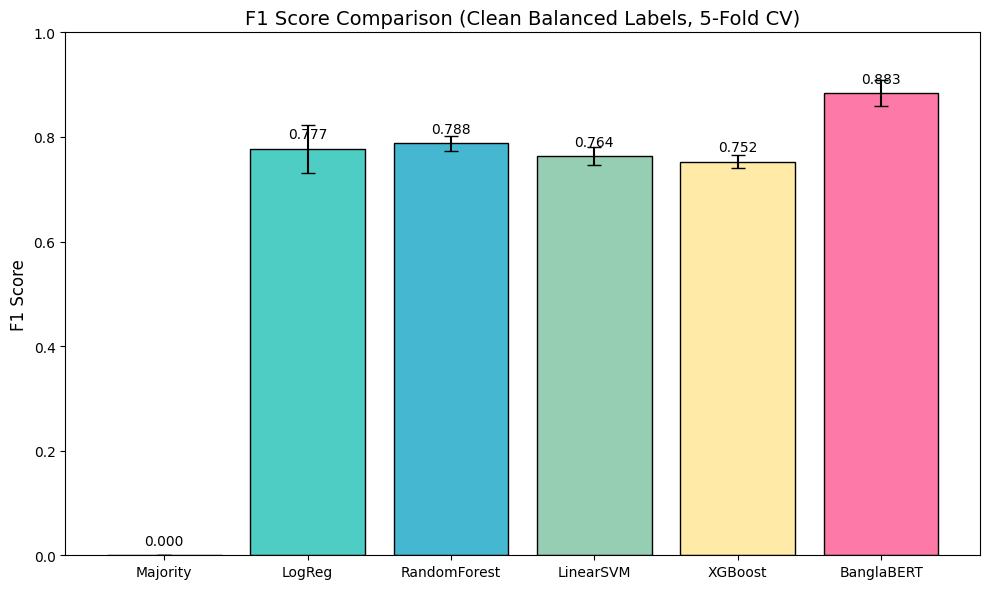

Saved: f1_comparison_clean.png


In [10]:
# === VISUALIZATION ===
import matplotlib.pyplot as plt

methods = ['Majority', 'LogReg', 'RandomForest', 'LinearSVM', 'XGBoost', 'BanglaBERT']
f1_means = [0, logreg_results['f1_mean'], rf_results['f1_mean'],
            svm_results['f1_mean'],
            xgb_results['f1_mean'] if xgb_results else 0,
            banglabert_summary['mean_f1']]
f1_stds = [0, logreg_results['f1_std'], rf_results['f1_std'],
           svm_results['f1_std'],
           xgb_results['f1_std'] if xgb_results else 0,
           banglabert_summary['std_f1']]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gray', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#FD79A8']
bars = ax.bar(methods, f1_means, yerr=f1_stds, capsize=5, color=colors, edgecolor='black')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison (Clean Balanced Labels, 5-Fold CV)', fontsize=14)
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'f1_comparison_clean.png', dpi=150)
plt.show()
print(f'Saved: f1_comparison_clean.png')

In [11]:
# === SAVE ALL RESULTS ===
all_results = {
    'dataset': 'Swarabyanjan_BEST_BALANCED_1to1.csv',
    'total_samples': int(len(y)),
    'yellow_samples': int(y.sum()),
    'non_yellow_samples': int((y == 0).sum()),
    'cv_folds': N_FOLDS,
    'seed': SEED,
    'classical': {
        'LogReg': {k: v for k, v in logreg_results.items() if not isinstance(v, np.ndarray)},
        'RandomForest': {k: v for k, v in rf_results.items() if not isinstance(v, np.ndarray)},
        'LinearSVM': {k: v for k, v in svm_results.items() if not isinstance(v, np.ndarray)},
    },
    'banglabert': banglabert_summary,
}
if xgb_results:
    all_results['classical']['XGBoost'] = {k: v for k, v in xgb_results.items() if not isinstance(v, np.ndarray)}

with open(OUTPUT_DIR / 'all_results_clean.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print('='*70)
print('ALL EXPERIMENTS COMPLETE')
print('='*70)
print(f'\nDataset: {len(y)} articles ({y.sum()}Y + {(y==0).sum()}NY)')
print(f'\nResults:')
print(f'  LogReg:        F1={logreg_results["f1_mean"]:.4f}')
print(f'  RandomForest:  F1={rf_results["f1_mean"]:.4f}')
print(f'  LinearSVM:     F1={svm_results["f1_mean"]:.4f}')
if xgb_results:
    print(f'  XGBoost:       F1={xgb_results["f1_mean"]:.4f}')
print(f'  BanglaBERT:    F1={banglabert_summary["mean_f1"]:.4f}')
print(f'\nOutput files:')
for f in sorted(OUTPUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}')

ALL EXPERIMENTS COMPLETE

Dataset: 766 articles (383Y + 383NY)

Results:
  LogReg:        F1=0.7771
  RandomForest:  F1=0.7879
  LinearSVM:     F1=0.7636
  XGBoost:       F1=0.7524
  BanglaBERT:    F1=0.8831

Output files:
  __notebook__.ipynb
  all_results_clean.json
  banglabert_clean_predictions.csv
  banglabert_clean_results.json
  f1_comparison_clean.png
  master_comparison_clean.csv
